In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv("C:\Datasets\IDS_Dataset\DDoS-Friday-no-metadata.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Mohammad Saquib\AppData\Local\Temp\ipykernel_18876\1352318388.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\Datasets\IDS_Dataset\DDoS-Friday-no-metadata.csv")


In [3]:
df.head(5)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [4]:
df.shape

(221264, 78)

In [5]:
df["Label"].value_counts()

Label
DDoS      128014
Benign     93250
Name: count, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221264 entries, 0 to 221263
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  221264 non-null  int64  
 1   Flow Duration             221264 non-null  int64  
 2   Total Fwd Packets         221264 non-null  int64  
 3   Total Backward Packets    221264 non-null  int64  
 4   Fwd Packets Length Total  221264 non-null  int64  
 5   Bwd Packets Length Total  221264 non-null  int64  
 6   Fwd Packet Length Max     221264 non-null  int64  
 7   Fwd Packet Length Min     221264 non-null  int64  
 8   Fwd Packet Length Mean    221264 non-null  float64
 9   Fwd Packet Length Std     221264 non-null  float64
 10  Bwd Packet Length Max     221264 non-null  int64  
 11  Bwd Packet Length Min     221264 non-null  int64  
 12  Bwd Packet Length Mean    221264 non-null  float64
 13  Bwd Packet Length Std     221264 non-null  f

In [7]:
df['Protocol'].value_counts()

Protocol
6     190165
17     31045
0         54
Name: count, dtype: int64

In [8]:
# Define and APPLY the drop to ensure parity with other models
cols_to_drop = [
    "Fwd Packets Length Total", "Bwd Packets Length Total", "Fwd Packet Length Max", 
    "Bwd Packet Length Max", "Fwd Packet Length Min", "Bwd Packet Length Min",
    "Fwd Packet Length Std", "Bwd Packet Length Std", "Flow IAT Std", "Flow IAT Total",
    "Fwd IAT Std", "Fwd IAT Max", "Fwd IAT Min", "Bwd IAT Total", "Bwd IAT Std", 
    "Bwd IAT Max", "Bwd IAT Min", "Fwd PSH Flags", "Bwd PSH Flags", "Fwd URG Flags", 
    "Bwd URG Flags", "Packet Length Variance", "PSH Flag Count", "URG Flag Count", 
    "CWE Flag Count", "ECE Flag Count", "Down/Up Ratio", "Avg Packet Size",
    "Avg Fwd Segment Size", "Avg Bwd Segment Size", "Fwd Avg Bytes/Bulk", 
    "Fwd Avg Packets/Bulk", "Fwd Avg Bulk Rate", "Bwd Avg Bytes/Bulk", 
    "Bwd Avg Packets/Bulk", "Bwd Avg Bulk Rate", "Subflow Bwd Bytes",
    "Init Fwd Win Bytes", "Init Bwd Win Bytes", "Fwd Act Data Packets", 
    "Fwd Seg Size Min", "Active Mean", "Active Std", "Active Max", "Active Min",
    "Idle Mean", "Idle Std", "Idle Max", "Idle Min"
]
df = df.drop(columns=cols_to_drop, axis=1, errors='ignore')
# Clean any infinity or NaN values resulting from scaling
df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

In [9]:
df.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packet Length Mean',
       'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total',
       'Fwd IAT Mean', 'Bwd IAT Mean', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'ACK Flag Count', 'Subflow Fwd Packets',
       'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Label'],
      dtype='object')

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

In [11]:
df.shape

(221264, 30)

In [12]:
X = df.drop(columns=["Label"])
y = df["Label"]

In [13]:
print(df.isnull().sum())

Protocol                  0
Flow Duration             0
Total Fwd Packets         0
Total Backward Packets    0
Fwd Packet Length Mean    0
Bwd Packet Length Mean    0
Flow Bytes/s              0
Flow Packets/s            0
Flow IAT Mean             0
Flow IAT Max              0
Flow IAT Min              0
Fwd IAT Total             0
Fwd IAT Mean              0
Bwd IAT Mean              0
Fwd Header Length         0
Bwd Header Length         0
Fwd Packets/s             0
Bwd Packets/s             0
Packet Length Min         0
Packet Length Max         0
Packet Length Mean        0
Packet Length Std         0
FIN Flag Count            0
SYN Flag Count            0
RST Flag Count            0
ACK Flag Count            0
Subflow Fwd Packets       0
Subflow Fwd Bytes         0
Subflow Bwd Packets       0
Label                     0
dtype: int64


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Scale the SMOTE data
X_test_scaled = scaler.transform(X_test)

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(pd.Series(y_train_res).value_counts())

ValueError: The specified ratio required to remove samples from the minority class while trying to generate new samples. Please increase the ratio.

In [ ]:
from sklearn.linear_model import LogisticRegression
import numpy as np

model = LogisticRegression(max_iter=1000, warm_start=True, solver="saga", class_weight="balanced")

model.fit(X_train_res[:100], y_train_res[:100])

C:\Users\Mohammad Saquib\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(class_weight='balanced', max_iter=1, solver='saga',
                   warm_start=True)

In [ ]:
# y_pred = model.predict(X_test)
# print(y_pred)

y_prob = model.predict_proba(X_test_scaled)
print(y_prob)

[[0.04903712 0.95096288]
 [0.37775781 0.62224219]
 [0.46413222 0.53586778]
 ...
 [0.55510239 0.44489761]
 [0.23445633 0.76554367]
 [0.13902853 0.86097147]]


In [ ]:
from sklearn.metrics import classification_report

# Use the hard predictions for the report
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

              precision    recall  f1-score   support

      Benign       1.00      0.73      0.84     18715
      Attack       0.83      1.00      0.91     25538

    accuracy                           0.88     44253
   macro avg       0.92      0.86      0.87     44253
weighted avg       0.90      0.88      0.88     44253



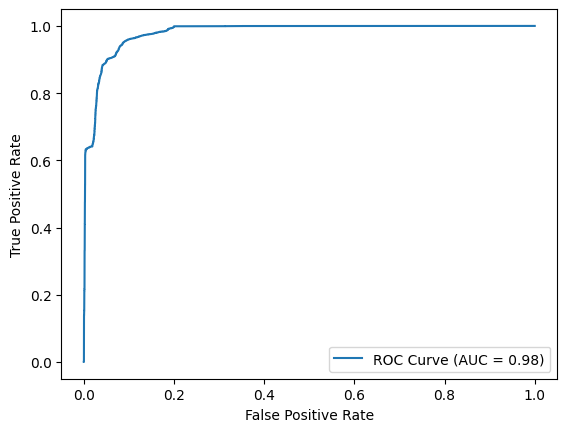

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Use the probabilities you already calculated
# y_probs[:, 1] is the probability of the 'Attack' class
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:, 1])
auc_score = roc_auc_score(y_test, y_prob[:, 1])

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [ ]:
import joblib

# Save the model to a pkl file
joblib.dump(model, 'model_1.pkl') # Change name for each file
print("Model saved as pkl for Federated Aggregation.")

Model saved as pkl for Federated Aggregation.
